# Superstore Profitability Analysis 

**Business Context:**
Superstore Inc. has been experiencing an increase in sales volume. Ηowever, overall profitability remains stagnant or is even declining in certain areas. 

**Objective:**
To identify the "weak links" in the sales funnel (product categories, regions, discount levels) and propose strategic, actionable insights to improve the overall profit margin.

# 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Data Loading & Exploration

In [7]:
df = pd.read_csv("../superstore/data/SampleSuperstore.csv")

In [8]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (9994, 13)


In [10]:
print("columns in the dataset:", df.columns)

columns in the dataset: Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


In [11]:
#information about the dataset
print("Information about the dataset:")
print(df.info())

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB
None


In [12]:
df.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [38]:
#descriptive statistics of the dataset
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [13]:
#check for null values in the dataset
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [14]:
#check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(17)

In [15]:
#drop duplicate rows if any
df.drop_duplicates(inplace=True)
print("Shape of the dataset after dropping duplicates:", df.shape)

Shape of the dataset after dropping duplicates: (9977, 13)


**Data Quality Check:** 
The dataset was loaded successfully, and no missing values (Nulls) were found. We identified and removed 17 duplicate records to ensure data integrity. We are now working with a clean dataset of 9,977 order records.

# 3. Performance by Category and Sub-Category
**Question:** Which product categories drive our profitability and which ones are burning money? We calculate the Profit Margin % [(Profit / Sales) * 100].

In [21]:
#per category
category_stats = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

category_stats['Profit Margin %'] = (category_stats['Profit'] / category_stats['Sales']) * 100
category_stats = category_stats.sort_values('Profit Margin %')

print("====== Per Category (scaled from worst to best) ======")
print(category_stats)
print("\n")

#per sub-category
subcategory_stats = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

subcategory_stats['Profit Margin %'] = (subcategory_stats['Profit'] / subcategory_stats['Sales']) * 100
subcategory_stats = subcategory_stats.sort_values('Profit Margin %')

print("====== Per Sub-Category ======")
print(subcategory_stats)
print("\n")

====== Per Category (scaled from worst to best) ======
                       Sales       Profit  Profit Margin %
Category                                                  
Furniture        741306.3133   18421.8137         2.485047
Office Supplies  718735.2440  122364.6608        17.024998
Technology       836154.0330  145454.9481        17.395712


====== Per Sub-Category ======
                    Sales      Profit  Profit Margin %
Sub-Category                                          
Tables        206965.5320 -17725.4811        -8.564460
Bookcases     114879.9963  -3472.5560        -3.022768
Supplies       46673.5380  -1189.0995        -2.547695
Machines      189238.6310   3384.7569         1.788618
Chairs        327777.7610  26567.1278         8.105226
Storage       223843.6080  21278.8264         9.506113
Phones        330007.0540  44515.7306        13.489327
Furnishings    91683.0240  13052.7230        14.236794
Binders       203409.1690  30228.0003        14.860687
Appliances  

========= PROFIT MARGIN % PER CATEGORY ==========


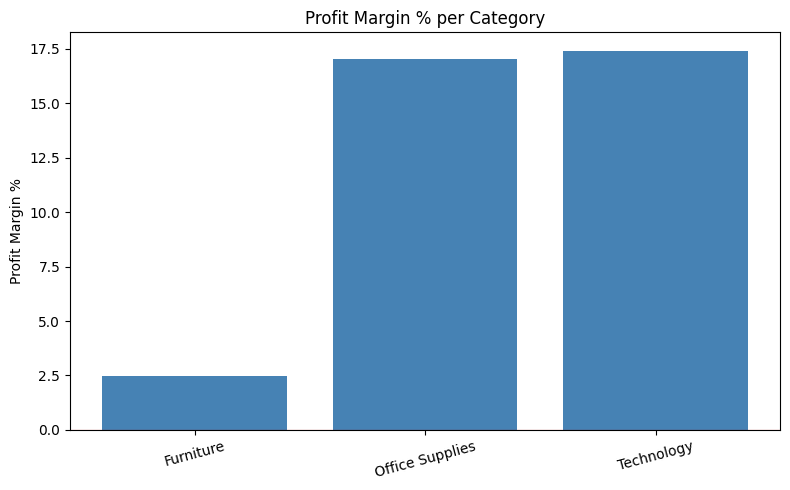



========= PROFIT MARGIN % PER SUB-CATEGORY ==========


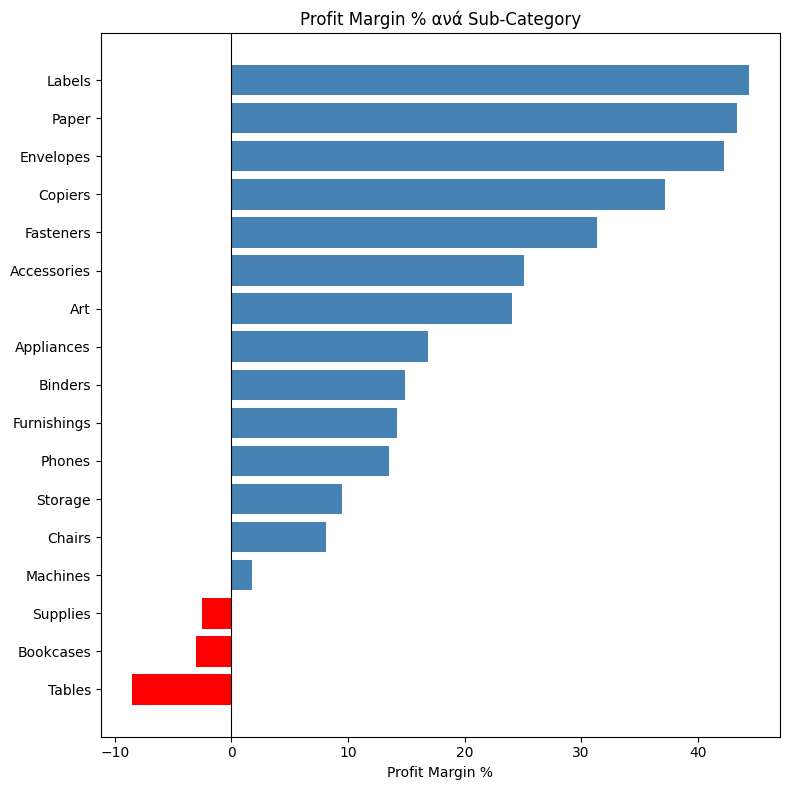

In [39]:
# bar chart for profit margin % per category

print('========= PROFIT MARGIN % PER CATEGORY ==========')

category_stats_sorted = category_stats.sort_values('Profit Margin %')

plt.figure(figsize=(8, 5))
plt.bar(category_stats_sorted.index, category_stats_sorted['Profit Margin %'], color='steelblue')
plt.axhline(0, color='red', linewidth=0.8)  # a line at 0 so we can see wich are negative and which are positive
plt.title('Profit Margin % per Category')
plt.ylabel('Profit Margin %')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print('\n')

#horizontal bar chart for profit margin % per sub-category
print('========= PROFIT MARGIN % PER SUB-CATEGORY ==========')

subcat_sorted = subcategory_stats.sort_values('Profit Margin %')

plt.figure(figsize=(8, 8))
colors = ['red' if x < 0 else 'steelblue' for x in subcat_sorted['Profit Margin %']]
plt.barh(subcat_sorted.index, subcat_sorted['Profit Margin %'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)  # a line at 0 so we can see wich are negative and which are positive
plt.title('Profit Margin % ανά Sub-Category')
plt.xlabel('Profit Margin %')
plt.tight_layout()
plt.show()

**Insights:**
* **Technology** and **Office Supplies** are the backbone of our profitability, with a margin of ~17%.
* The **Furniture** category is the company's "Achilles' heel" (margin of only 2.48%).
* Drilling down into sub-categories, we can see that **Tables (-8.56%)** and **Bookcases (-3.02%)** are currently being sold at a loss.

# 4. Customer Segment and Regional Analysis
**Question:** Which geographic regions and customer types bring the most value to the company?

In [23]:
#per region
region_stats = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

region_stats['Profit Margin %'] = (region_stats['Profit'] / region_stats['Sales']) * 100
region_stats = region_stats.sort_values('Profit Margin %')

print("====== Per Region ======")
print(region_stats)
print("\n")

#per segment
segment_stats = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

segment_stats['Profit Margin %'] = (segment_stats['Profit'] / segment_stats['Sales']) * 100
segment_stats = segment_stats.sort_values('Profit Margin %')

print("====== Per Segment ======")
print(segment_stats)
print("\n")

====== Per Region ======
               Sales       Profit  Profit Margin %
Region                                            
Central  500782.8528   39655.8752         7.918777
South    391721.9050   46749.4303        11.934342
East     678435.1960   91506.3092        13.487848
West     725255.6365  108329.8079        14.936776


====== Per Segment ======
                    Sales       Profit  Profit Margin %
Segment                                                
Consumer     1.160833e+06  134007.4413        11.544078
Corporate    7.060701e+05   91954.9798        13.023491
Home Office  4.292927e+05   60279.0015        14.041470




**Insights:**
* **Geographically:** The *West Region* (14.9%) performs the best, while the *Central Region* (7.9%) significantly underperforms, dragging down the company's average.
* **Segments:** B2B customers (*Home Office* and *Corporate*) yield the highest profit margins. In contrast, regular consumers (*Consumer segment*), despite driving the highest sales volume, generate the lowest margin (11.5%).

# 5. The Impact of Discounts (Discount vs. Profit)
**Question:** Is our discount strategy driving us into losses? We will create Discount Bins to find the critical tipping point.

In [27]:
#5.1 create discount bins
bins = [-0.01, 0, 0.2, 0.4, 1]
labels = ['0% (No Discount)', '1-20% (Low Discount)', '21-40% (Medium Discount)', '41-100% (High Discount)']

df['Discount Bin'] = pd.cut(df['Discount'], bins=bins, labels=labels)
#pd.cut takes numeric values and segments them into bins. Here, we are creating bins for discount percentages.

#5.2 group by discount bins and calculate total sales and profit
discount_stats = df.groupby('Discount Bin').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

discount_stats['Profit Margin %'] = (discount_stats['Profit'] / discount_stats['Sales']) * 100
print("====== Per Discount Bin ======")
print(discount_stats)
print("\n")

#5.3 combo stats for category and discount bins
combo_stats = df.groupby(['Category', 'Discount Bin']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

combo_stats['Profit Margin %'] = (combo_stats['Profit'] / combo_stats['Sales']) * 100
print("====== Per Category and Discount Bin ======")
print(combo_stats)

====== Per Discount Bin ======
                                 Sales       Profit  Profit Margin %
Discount Bin                                                        
0% (No Discount)          1.087278e+06  320844.4073        29.508970
1-20% (Low Discount)      8.464328e+05  100754.7755        11.903458
21-40% (Medium Discount)  2.338565e+05  -35805.4067       -15.310844
41-100% (High Discount)   1.286287e+05  -99552.3535       -77.395140


====== Per Category and Discount Bin ======
                                                Sales       Profit  \
Category        Discount Bin                                         
Furniture       0% (No Discount)          255613.1600   58091.5585   
                1-20% (Low Discount)      290823.7845   14795.9525   
                21-40% (Medium Discount)  159296.8428  -29261.7926   
                41-100% (High Discount)    35572.5260  -25203.9047   
Office Supplies 0% (No Discount)          441931.2000  130404.4284   
                1-2

C:\Users\Elena\AppData\Local\Temp\ipykernel_11332\292521297.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_stats = df.groupby('Discount Bin').agg({
C:\Users\Elena\AppData\Local\Temp\ipykernel_11332\292521297.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combo_stats = df.groupby(['Category', 'Discount Bin']).agg({


========= SCATTER PLOT DISCOUNT VS PROFIT MARGIN ==========


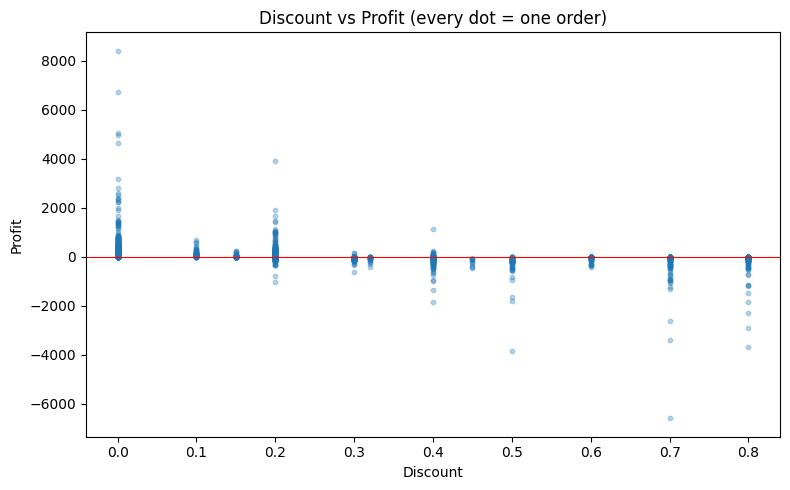



========= PROFIT MARGIN % PER DISCOUNT BIN ==========


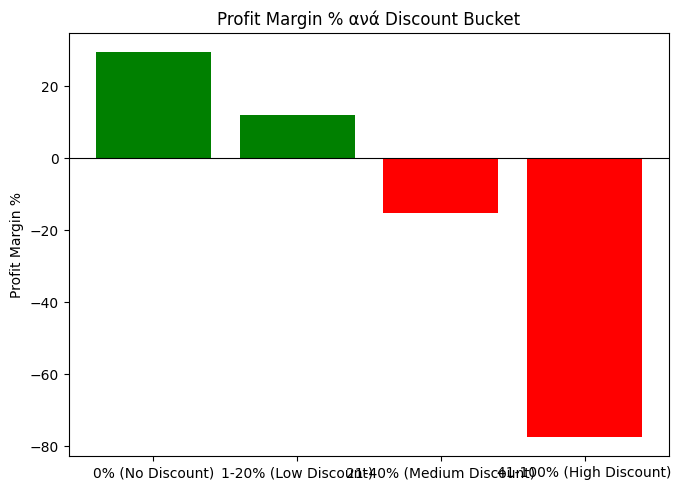

In [40]:
#3 scatter plot discount vs profit margin
print('========= SCATTER PLOT DISCOUNT VS PROFIT MARGIN ==========')

plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, s=10)
plt.axhline(0, color='red', linewidth=0.8)
plt.title('Discount vs Profit (every dot = one order)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()
print('\n')

#4 profit margin % per discount bin
print('========= PROFIT MARGIN % PER DISCOUNT BIN ==========')

plt.figure(figsize=(7, 5))
colors = ['red' if x < 0 else 'green' for x in discount_stats['Profit Margin %']]
plt.bar(discount_stats.index.astype(str), discount_stats['Profit Margin %'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Profit Margin % ανά Discount Bucket')
plt.ylabel('Profit Margin %')
plt.tight_layout()
plt.show()

**Insights (Critical Finding):**
The analysis reveals that our discount strategy is highly problematic.
* Discounts up to 20% (Low Discount) maintain profitability at a healthy level (11.9%).
* Discounts over 20% destroy profitability: **-15.3% margin** for medium discounts and a staggering **-77.3% margin** for high discounts (41-100%).

# 6. Geographic Deep-Dive: The Most Unprofitable States
**Question:** Having identified that regions like "Central" are underperforming, which specific States should we focus on to stop the financial bleeding?

========= WORST 10 STATES BY PROFIT MARGIN ==========
                      Sales      Profit  Profit Margin %
State                                                   
Ohio             77976.7640 -16959.3178       -21.749194
Colorado         32108.1180  -6527.8579       -20.330864
Tennessee        30661.8730  -5341.6936       -17.421289
Illinois         80162.5370 -12601.6500       -15.720124
Texas           170124.5418 -25750.9833       -15.136548
North Carolina   55603.1640  -7490.9122       -13.472097
Pennsylvania    116496.3620 -15565.4035       -13.361279
Arizona          35282.0010  -3427.9246        -9.715789
Oregon           17420.7820  -1194.0993        -6.854453
Florida          89473.7080  -3399.3017        -3.799219




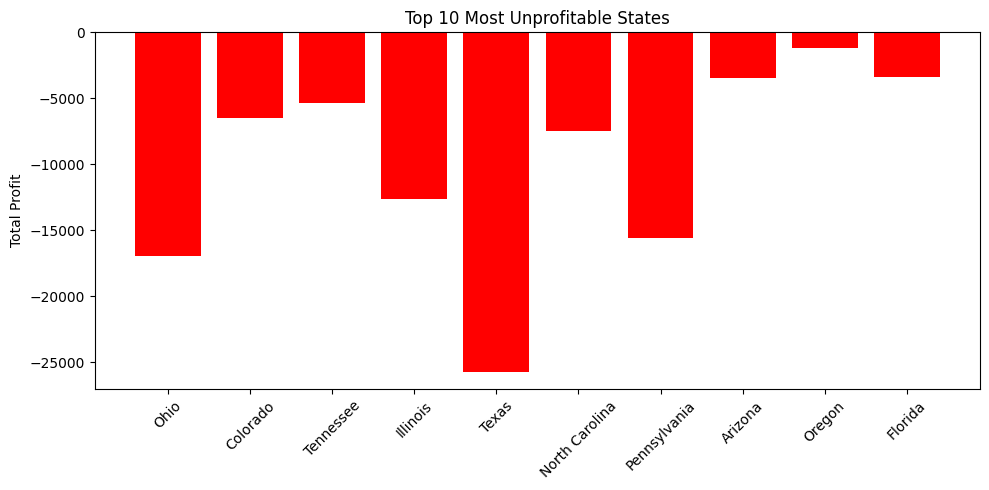

In [36]:
# i have already calculated the profit per region but let;s do it again
#but now lets do it by sales, profit , margin and states

state_stats = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).copy()

state_stats['Profit Margin %'] = (state_stats['Profit'] / state_stats['Sales']) * 100

#filter the 10 worst states by profit margin
worst_states = state_stats.sort_values('Profit Margin %').head(10)
print('========= WORST 10 STATES BY PROFIT MARGIN ==========')
print(worst_states)
print('\n')

#visualize the worst 10 states by profit margin
plt.figure(figsize=(10, 5))
plt.bar(worst_states.index, worst_states['Profit'], color='red')
plt.title('Top 10 Most Unprofitable States')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
The states of **Texas**, **Ohio**, and **Pennsylvania** represent a "black hole" for our profitability, generating total losses of tens of thousands of dollars. The issue here is localized and requires immediate investigation (e.g., excessively high shipping costs or aggressive competition forcing deep discounts).

# 7. Correlation Matrix
We statistically check the relationship between numerical variables to validate our previous findings.

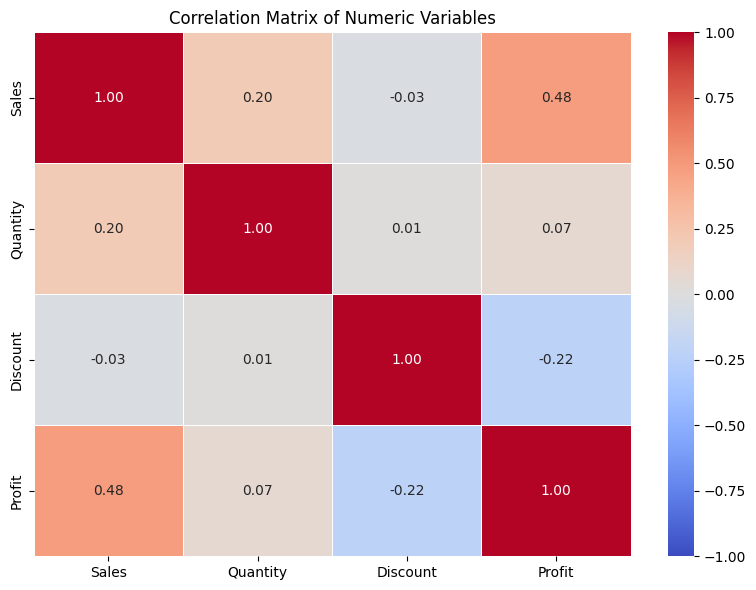

In [37]:
# we only select the numeric columns for correlation analysis
numeric_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]

#corelation matrix
corr_matrix = numeric_cols.corr()

#heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

**Insights:**
It is statistically confirmed (strong negative correlation) that as the Discount increases, the Profit decreases.

# 8. Executive Summary & Actionable Insights

Based on the descriptive analysis above, we have identified the key factors consuming the company's profit margin despite the high sales volume. Below are the key findings and proposed strategic solutions:

### 1. Discount Strategy (Discount Cap)
As confirmed by the Correlation Matrix, there is a strong negative correlation between Discount and Profit. Discounts up to 20% maintain a healthy profit margin (~11.9%). However, discounts of 21% and above destroy profitability, plummeting to a chaotic -119% in categories like Office Supplies.
* **Actionable Insight:** Implement a system-wide Discount Cap at 20%. Any discount exceeding this threshold should require special management approval (e.g., only for clearing out obsolete inventory).

### 2. Product Mix Restructuring (Furniture Category)
The *Technology* and *Office Supplies* categories drive profitability (margin ~17%). Conversely, *Furniture* underperforms (2.48%), with *Tables* (-8.56%) and *Bookcases* (-3.02%) being clear loss-makers.
* **Actionable Insight:** Immediate review of the Furniture strategy. We recommend renegotiating costs with suppliers, adjusting retail prices, or halting promotional campaigns for Tables.

### 3. Geographic Targeting (Unprofitable States)
Although the *West Region* performs exceptionally well, we identified a massive profit drain in specific states, mainly in the Central and East Regions. The bottom 3 states are Texas, Ohio, and Pennsylvania.
* **Actionable Insight:** Investigate operational costs (e.g., high shipping fees) in these 3 states and drastically reduce the local marketing budget until the local profit margin recovers.

### 4. B2B vs. B2C (Customer Targeting)
The B2B audience (*Home Office* 14% & *Corporate* 13% margin) is significantly more profitable than regular consumers (*Consumer* 11.5%), even though the latter brings in more total revenue.
* **Actionable Insight:** Shift the advertising budget towards targeted B2B campaigns to improve the overall Sales Mix.

---
**Data Limitations:**
* **Seasonality:** The current dataset did not include chronological data (*Order Date*), therefore a Trend/Seasonality Analysis was not feasible.
* **Market Basket Analysis:** The absence of an *Order ID* or *Customer ID* variable prevents us from analyzing customer behavior at the basket level (e.g., whether loss-making Tables act as "loss leaders" to drive purchases of profitable items in the same order).
